# Pseudo Cryo-ET Data Generation from Membrane Mesh
This notebook demonstrates how to:
1. Load Mem3DG-generated membrane mesh data (`data/raw/biconcave.nc`).
2. Generate pseudo cryo-ET data.
3. Save and visualize the output.


In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

Pseudo cryo-ET data saved to: ../data/synthetic/flip_noise/bud_04_f00_wz.mrc


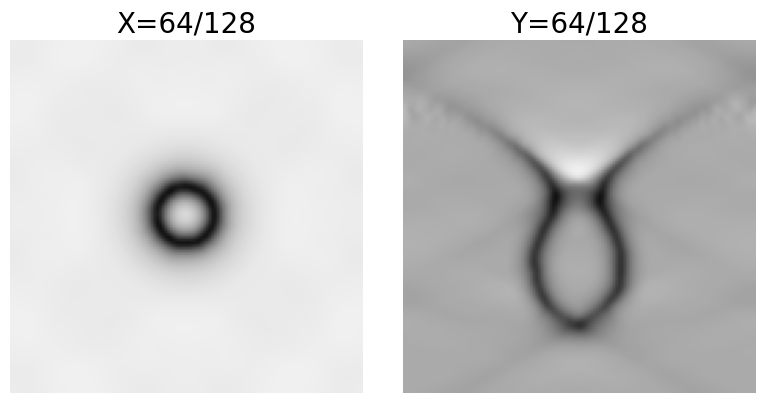

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation.mesh_to_cryoet import generate_pseudo_cryoet, plot_single_slice

shape="bud_04"
# missing_ratio=0.998
flip_ratio=0.0
sigma=1
wedge_axis='z'
# num_patch=10
# rad_patch=25

# Path to Mem3DG-generated trajectory file
# input_file = "../data/raw/biconcave.nc"
input_file = "../data/raw/bud.nc"
# input_file_1 = "../data/raw/oblate.nc"
# input_file_2 = "../data/raw/sphere.nc"

# Path to save the generated pseudo cryo-ET data
# output_file = "../data/synthetic/bud.mrc"
# output_file = "../data/synthetic/multi.mrc"
# output_file = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_blur_{str(sigma).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"
# output_file = "../data/synthetic/biconcave_test.mrc"
# output_file = None

# output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"

# Generate pseudo cryo-ET volume
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma) # for biconcave
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.2) # for bud
# pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4) # for multi
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0, missing_ratio=missing_ratio)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0, flip_ratio=flip_ratio)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0, num_patch=num_patch, rad_patch=rad_patch)

# for biconcave
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, flip_ratio=flip_ratio, wedge_axis=wedge_axis) # noise + wedge

# for bud
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.2, flip_ratio=flip_ratio, missing_wedge=False) # noise only
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.2, flip_ratio=flip_ratio, wedge_axis=wedge_axis) # noise + wedge

# for bud_04
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4, flip_ratio=flip_ratio, missing_wedge=False) # noise only
pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4, flip_ratio=flip_ratio, wedge_axis=wedge_axis) # noise + wedge

# for multi
# pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4, flip_ratio=flip_ratio, missing_wedge=False) # noise only
# pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4, flip_ratio=flip_ratio, wedge_axis=wedge_axis) # noise + wedge


thre = None
# thre = 0.8
# Visualize the middle slice in different directions
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_single_slice(pseudo_cryoET, ax=axes[0], axis='x', thre=thre)  # X-direction
plot_single_slice(pseudo_cryoET, ax=axes[1], axis='y', thre=thre)  # Y-direction
# plot_single_slice(pseudo_cryoET, axis='z', thre=thre)  # Z-direction

plt.tight_layout()
plt.show()

# test_data = np.where(pseudo_cryoET > thre, 1, 0)
# test_data[64, :, :]

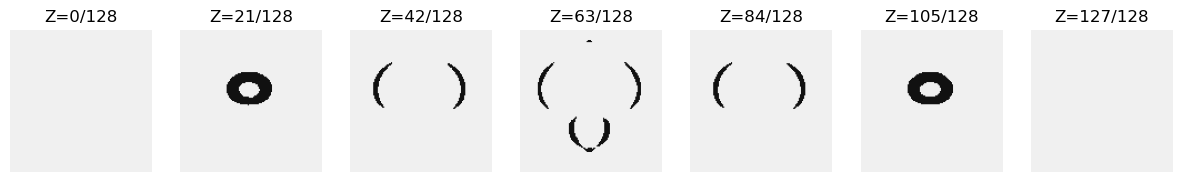

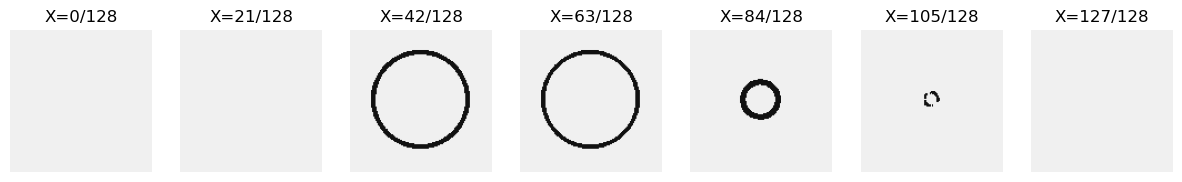

In [26]:
from data_generation.mesh_to_cryoet import plot_multiple_slices
import mrcfile

shape="multi"
# missing_ratio=0.998
flip_ratio=0.0
wedge_axis="z"
# sigma = 5

# output_file = "../data/synthetic/biconcave.mrc"
# output_file = "../data/synthetic/bud.mrc"
# output_file = "../data/synthetic/multi.mrc"
# output_file = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_blur_{str(sigma).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"
# output_file = "../data/synthetic/biconcave_test.mrc"

# output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"


# Load pseudo cryo-ET data
with mrcfile.open(output_file, permissive=True) as mrc:
    volume = mrc.data

# Correct function call
thre = 0.6
# thre = None
plot_multiple_slices(volume, axis='z', num_slices=7, thre=thre)
plot_multiple_slices(volume, axis='x', num_slices=7, thre=thre)


In [3]:
# measure length

import numpy as np
from netCDF4 import Dataset

# Path to Mem3DG-generated trajectory file
input_file = "../data/raw/biconcave.nc"
data = Dataset(input_file, 'r')


# Access the 'Trajectory' group
coords = data.groups['Trajectory'].variables['coordinates'][-1]
coords = coords.reshape(-1, 3)

min_bound = np.min(coords, axis=0)
max_bound = np.max(coords, axis=0)
extent = max_bound - min_bound

print("x-length = ", extent[0])
print("y-length = ", extent[1])
print("z-length = ", extent[2])


x-length =  2.37126752123156
y-length =  2.37008613382773
z-length =  0.9744919523084066
